# Combined Metrics for Future/Past Analysis

This notebook compiles comprehensive metrics for each electrode:
1. Metadata (electrode, subject, roi, etc)
2. Max joint performance
3. AUC past (lag 0:5000)
4. AUC future (lag -5000:0)
5. Word peak share
6. Sigmoid fitting slope (k) and inflection point (x0)
7. Future diff (max at lag <=0) between original and rand_m_diff_w
8. Past diff (max at lag >=0) between original and rand_m_diff_w
9. Future diff (max at lag <=0) between original and opp_m_diff_w
10. Past diff (max at lag >=0) between original and opp_m_diff_w

In [11]:
import matplotlib.pyplot as plt
import argparse
import pandas as pd
import numpy as np
import sys
from matplotlib.backends.backend_pdf import PdfPages

sys.path.append('/scratch/gpfs/HASSON/ij9216/projects/code/247/247-plotting/scripts')
import tfsplt_future_past_utils as pu

In [4]:
# Configuration
res_d = "/scratch/gpfs/HASSON/ij9216/projects/code/247/247-encoding-dev/results/tfs"
thresh_joint = 0.1

print(f"Results directory: {res_d}")
print(f"Joint threshold: {thresh_joint}")

Results directory: /scratch/gpfs/HASSON/ij9216/projects/code/247/247-encoding-dev/results/tfs
Joint threshold: 0.1


## Load Data

Load all necessary datasets:
- Original (no rephrase) - comprehension and production
- Control conditions: rand_m_diff_w and opp_m_diff_w

In [5]:
# Get shared indices for different lag ranges
shared_ind_l, shared_ind_m = pu.get_shared_indices(
    np.arange(-120000, 120001, 50), 
    np.arange(-60000, 60001, 50)
)

print(f"Shared indices (large): {len(shared_ind_l)}")
print(f"Shared indices (medium): {len(shared_ind_m)}")

Shared indices (large): 2401
Shared indices (medium): 2401


In [6]:
# Load original (no rephrase) data - 60k lag range
print("Loading original data (60k lag range)...")
no_reph_c = pu.load_res_add_roi_threshold(
    f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-reph-translate-control_pca300_drop-short_mistral_comp.csv", 
    None
)
no_reph_p = pu.load_res_add_roi_threshold(
    f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-reph-translate-control_pca300_drop-short_mistral_prod.csv", 
    None
)

# Rename lag columns to numeric values
lag_cols = np.arange(-60000, 60001, 50)
for df in [no_reph_c, no_reph_p]:
    n_lag_cols = len(lag_cols)
    new_columns = list(lag_cols) + list(df.columns[n_lag_cols:])
    df.columns = new_columns

print(f"Comprehension shape (60k): {no_reph_c.shape}")
print(f"Production shape (60k): {no_reph_p.shape}")

Loading original data (60k lag range)...
Comprehension shape (60k): (2644, 2406)
Production shape (60k): (2644, 2406)
Comprehension shape (60k): (2644, 2406)
Production shape (60k): (2644, 2406)


In [7]:
# Load control conditions (120k lag range)
print("Loading rand_m_diff_w data...")
rand_c = pu.load_res_add_roi_threshold(
    f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag120k-50-all-static_future_past-reph-rand-m-diff-w-2_drop-short_mistral_comp.csv",
    None
)
rand_p = pu.load_res_add_roi_threshold(
    f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag120k-50-all-static_future_past-reph-rand-m-diff-w-2_drop-short_mistral_prod.csv",
    None
)

# Select shared columns with 60k data
rand_c = pu.select_shared_and_last_columns(rand_c, shared_ind_l)
rand_p = pu.select_shared_and_last_columns(rand_p, shared_ind_l)

print(f"rand_m_diff_w comp shape: {rand_c.shape}")
print(f"rand_m_diff_w prod shape: {rand_p.shape}")

Loading rand_m_diff_w data...
rand_m_diff_w comp shape: (2644, 2406)
rand_m_diff_w prod shape: (2633, 2406)
rand_m_diff_w comp shape: (2644, 2406)
rand_m_diff_w prod shape: (2633, 2406)


In [8]:
print("Loading opp_m_diff_w data...")
opp_c = pu.load_res_add_roi_threshold(
    f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag120k-50-all-static_future_past-reph-opp-m-diff-w_drop-short_mistral_comp.csv",
    None
)
opp_p = pu.load_res_add_roi_threshold(
    f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag120k-50-all-static_future_past-reph-opp-m-diff-w_drop-short_mistral_prod.csv",
    None
)

# Select shared columns with 60k data
opp_c = pu.select_shared_and_last_columns(opp_c, shared_ind_l)
opp_p = pu.select_shared_and_last_columns(opp_p, shared_ind_l)

print(f"opp_m_diff_w comp shape: {opp_c.shape}")
print(f"opp_m_diff_w prod shape: {opp_p.shape}")

Loading opp_m_diff_w data...
opp_m_diff_w comp shape: (2640, 2406)
opp_m_diff_w prod shape: (2632, 2406)
opp_m_diff_w comp shape: (2640, 2406)
opp_m_diff_w prod shape: (2632, 2406)


## Calculate Metrics

Now we'll calculate each metric for both comprehension and production.

### 1. Max Joint Performance

In [9]:
# Get max joint performance for comprehension
print("Calculating max joint performance...")
max_joint_c = pu.get_max_joint_performance(no_reph_c, thresh=0.0)  # Get all, threshold later
max_joint_p = pu.get_max_joint_performance(no_reph_p, thresh=0.0)

# Add mode column
max_joint_c['mode'] = 'comp'
max_joint_p['mode'] = 'prod'

# Combine
max_joint = pd.concat([max_joint_c, max_joint_p], ignore_index=True)

print(f"Max joint comp: {len(max_joint_c)}")
print(f"Max joint prod: {len(max_joint_p)}")
print(f"Total: {len(max_joint)}")
print(f"\nSample:")
print(max_joint.head())

Calculating max joint performance...
Max joint comp: 658
Max joint prod: 648
Total: 1306

Sample:
   subject electrode                         roi  max_joint  mode
0      798       G47               supramarginal   0.061010  comp
1      798       G37                      postCG   0.047806  comp
2      798       G74        rostralmiddlefrontal   0.061329  comp
3      798        O3            inferiorparietal   0.182536  comp
4      798     DPMT4  Left-Cerebral-White-Matter   0.076593  comp


### 2-3. AUC Calculations

In [10]:
# Calculate AUC for future and past
# Comprehension: use 350ms threshold (exclude ±350ms window)
# Production: use 0ms threshold
print("Calculating AUC for future (comp: -5000 to 350, prod: -5000 to 0)...")
auc_future_c = pu.calculate_auc(no_reph_c, 'sentence', lag_start=-5000, lag_end=350)
auc_future_p = pu.calculate_auc(no_reph_p, 'sentence', lag_start=-5000, lag_end=0)

auc_future_c['mode'] = 'comp'
auc_future_c['direction'] = 'future'
auc_future_p['mode'] = 'prod'
auc_future_p['direction'] = 'future'

print(f"AUC future comp: {len(auc_future_c)}")
print(f"AUC future prod: {len(auc_future_p)}")


Calculating AUC for future (comp: -5000 to 350, prod: -5000 to 0)...
AUC future comp: 661
AUC future prod: 661
AUC future comp: 661
AUC future prod: 661


In [11]:
print("Calculating AUC for past (comp: 350 to 5000, prod: 0 to 5000)...")
auc_past_c = pu.calculate_auc(no_reph_c, 'sentence2', lag_start=350, lag_end=5000)
auc_past_p = pu.calculate_auc(no_reph_p, 'sentence2', lag_start=0, lag_end=5000)

auc_past_c['mode'] = 'comp'
auc_past_c['direction'] = 'past'
auc_past_p['mode'] = 'prod'
auc_past_p['direction'] = 'past'

print(f"AUC past comp: {len(auc_past_c)}")
print(f"AUC past prod: {len(auc_past_p)}")


Calculating AUC for past (comp: 350 to 5000, prod: 0 to 5000)...
AUC past comp: 661
AUC past prod: 661
AUC past comp: 661
AUC past prod: 661


In [12]:
# Combine AUC results
auc_all = pd.concat([auc_future_c, auc_future_p, auc_past_c, auc_past_p], ignore_index=True)

print(f"Total AUC calculations: {len(auc_all)}")
print(f"\nSample:")
print(auc_all.head())

Total AUC calculations: 2644

Sample:
   subject electrode                   roi    label3  lag_start  lag_end  \
0      798        O2      superiorparietal  sentence      -5000      350   
1      798       G67                   NaN  sentence      -5000      350   
2      798      PIT2              fusiform  sentence      -5000      350   
3      798       G80  rostralmiddlefrontal  sentence      -5000      350   
4      798       G78                   IFG  sentence      -5000      350   

          auc  n_lags  mode direction  
0   69.173766     108  comp    future  
1   59.476135     108  comp    future  
2  164.788991     108  comp    future  
3   60.130370     108  comp    future  
4   24.122761     108  comp    future  


### 4. Word Peak Share

In [13]:
print("Calculating word peak share...")
word_share_c = pu.get_word_peak_share(no_reph_c, thresh=0.0)  # Get all, threshold later
word_share_p = pu.get_word_peak_share(no_reph_p, thresh=0.0)

word_share_c['mode'] = 'comp'
word_share_p['mode'] = 'prod'

# Combine
word_share = pd.concat([word_share_c, word_share_p], ignore_index=True)

print(f"Word share comp: {len(word_share_c)}")
print(f"Word share prod: {len(word_share_p)}")
print(f"Total: {len(word_share)}")
print(f"\nSample:")
print(word_share.head())

Calculating word peak share...
Word share comp: 658
Word share prod: 648
Total: 1306

Sample:
label3  subject     electrode     joint  sentence  sentence2      word  \
0           625  EEGATO_01REF  0.131579  0.088197   0.115925  0.019485   
1           625  EEGATO_02REF  0.070359  0.056501   0.044049  0.023879   
2           625  EEGATO_03REF  0.054855  0.031514   0.050498  0.015998   
3           625  EEGATO_04REF  0.046813  0.034905   0.039961  0.016611   
4           625   EEGAT_01REF  0.134436  0.109077   0.136612  0.023929   

label3  word_peak_share  mode  
0              0.148084  comp  
1              0.339395  comp  
2              0.291642  comp  
3              0.354846  comp  
4              0.177993  comp  


### 5. Sigmoid Fitting

Fit sigmoid curves to sentence and sentence2 data in the -5s to +5s window around word onset.

In [14]:
# Fit sigmoids for comprehension (lag range -5000 to 5000ms)
print("Fitting sigmoids for comprehension data (this may take a few minutes)...")
sigmoid_c = pu.fit_sigmoids_to_df(no_reph_c, lag_start=-5000, lag_end=5000)

# Transform x0 to actual lag values (-5000 to 5000)
# x0 is in index space, need to convert to lag space
lag_step = 50  # ms per step
n_lags = len([c for c in no_reph_c.columns if isinstance(c, (int, float, np.integer, np.floating)) and -5000 <= float(c) <= 5000])
sigmoid_c['x0_lag'] = sigmoid_c['x0'] * lag_step - 5000
sigmoid_c['mode'] = 'comp'

print(f"\nSigmoid fits comp: {len(sigmoid_c)}")
print(f"Successful fits: {sigmoid_c['fit_success'].sum()}")
if sigmoid_c['fit_success'].sum() > 0:
    print(f"Mean R²: {sigmoid_c[sigmoid_c['fit_success']]['r_squared'].mean():.3f}")
else:
    print("Mean R²: No successful fits")

Fitting sigmoids for comprehension data (this may take a few minutes)...


/scratch/gpfs/HASSON/ij9216/conda_envs/env-sent-2/lib/python3.13/site-packages/numpy/_core/numeric.py:476: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


/scratch/gpfs/HASSON/ij9216/conda_envs/env-sent-2/lib/python3.13/site-packages/numpy/_core/numeric.py:476: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


/scratch/gpfs/HASSON/ij9216/conda_envs/env-sent-2/lib/python3.13/site-packages/numpy/_core/numeric.py:476: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


/scratch/gpfs/HASSON/ij9216/conda_envs/env-sent-2/lib/python3.13/site-packages/numpy/_core/numeric.py:476: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


...

/scratch/gpfs/HASSON/ij9216/conda_envs/env-sent-2/lib/python3.13/site-packages/numpy/_core/numeric.py:476: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


/scratch/gpfs/HASSON/ij9216/conda_envs/env-sent-2/lib/python3.13/site-packages/numpy/_core/numeric.py:476: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


/scratch/gpfs/HASSON/ij9216/conda_envs/env-sent-2/lib/python3.13/site-packages/numpy/_core/numeric.py:476: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


/scratch/gpfs/HASSON/ij9216/conda_envs/env-sent-2/lib/python3.13/site-packages/numpy/_core/numeric.py:476: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


Fitting row 1322/1322

Sigmoid fits comp: 1322
Successful fits: 1312
Mean R²: 0.606
Fitting row 1322/1322

Sigmoid fits comp: 1322
Successful fits: 1312
Mean R²: 0.606


In [15]:
# Fit sigmoids for production (lag range -5000 to 5000ms)
print("Fitting sigmoids for production data (this may take a few minutes)...")
sigmoid_p = pu.fit_sigmoids_to_df(no_reph_p, lag_start=-5000, lag_end=5000)

# Transform x0 to actual lag values (-5000 to 5000)
# x0 is in index space, need to convert to lag space
lag_step = 50  # ms per step
sigmoid_p['x0_lag'] = sigmoid_p['x0'] * lag_step - 5000
sigmoid_p['mode'] = 'prod'

print(f"\nSigmoid fits prod: {len(sigmoid_p)}")
print(f"Successful fits: {sigmoid_p['fit_success'].sum()}")
if sigmoid_p['fit_success'].sum() > 0:
    print(f"Mean R²: {sigmoid_p[sigmoid_p['fit_success']]['r_squared'].mean():.3f}")
else:
    print("Mean R²: No successful fits")

Fitting sigmoids for production data (this may take a few minutes)...


/scratch/gpfs/HASSON/ij9216/conda_envs/env-sent-2/lib/python3.13/site-packages/numpy/_core/numeric.py:476: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


/scratch/gpfs/HASSON/ij9216/conda_envs/env-sent-2/lib/python3.13/site-packages/numpy/_core/numeric.py:476: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


/scratch/gpfs/HASSON/ij9216/conda_envs/env-sent-2/lib/python3.13/site-packages/numpy/_core/numeric.py:476: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


/scratch/gpfs/HASSON/ij9216/conda_envs/env-sent-2/lib/python3.13/site-packages/numpy/_core/numeric.py:476: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


/scratch/gpfs/HASSON/ij9216/conda_envs/env-sent-2/lib/python3.13/site-packages/numpy/_core/numeric.py:476: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


Fitting row 1322/1322

Sigmoid fits prod: 1322
Successful fits: 1317
Mean R²: 0.463
Fitting row 1322/1322

Sigmoid fits prod: 1322
Successful fits: 1317
Mean R²: 0.463


In [16]:
# Combine sigmoid results
sigmoid_all = pd.concat([sigmoid_c, sigmoid_p], ignore_index=True)

print(f"Total sigmoid fits: {len(sigmoid_all)}")
print(f"\nSample:")
print(sigmoid_all.head())

Total sigmoid fits: 2644

Sample:
          L          x0         k         b  r_squared  fit_success  \
0  0.029098  131.914590  0.414945  0.012738   0.807394         True   
1  0.103244  135.671055  0.014669 -0.013556   0.881125         True   
2  0.019671   89.366239  0.127685  0.027614   0.508983         True   
3  0.050918   93.345272  0.102865  0.004193   0.912848         True   
4  0.111804  110.051423  1.131332  0.004535   0.946894         True   

                                        fitted_curve  peak_slope   direction  \
0  [0.012738157528920166, 0.012738157528920166, 0...    0.003019  increasing   
1  [-0.0011421885701480717, -0.000981088446339850...    0.000379  increasing   
2  [0.027614385903443492, 0.027614415577798826, 0...    0.000628  increasing   
3  [0.004196516716833594, 0.004196889549655151, 0...    0.001309  increasing   
4  [0.004534966328730357, 0.004534966328730357, 0...    0.031622  increasing   

  electrode                   roi    label3  subject  lag_

### 6-9. Control Condition Differences

Calculate differences between original and control conditions (rand_m_diff_w and opp_m_diff_w).

In [17]:
# Rename columns in control dataframes to match original
lag_cols_control = np.arange(-60000, 60001, 50)
for df in [rand_c, rand_p, opp_c, opp_p]:
    n_lag_cols = len(lag_cols_control)
    new_columns = list(lag_cols_control) + list(df.columns[n_lag_cols:])
    df.columns = new_columns

print("Columns renamed for control conditions.")

Columns renamed for control conditions.


In [18]:
# Calculate rand_m_diff_w differences - FUTURE
print("Calculating rand_m_diff_w differences for future (sentence, lag <= 0)...")
rand_future_c = pu.calculate_max_diff(no_reph_c, rand_c, 'sentence', lag_cutoff=0, direction='future')
rand_future_p = pu.calculate_max_diff(no_reph_p, rand_p, 'sentence', lag_cutoff=0, direction='future')

rand_future_c['mode'] = 'comp'
rand_future_c['control'] = 'rand_m_diff_w'
rand_future_p['mode'] = 'prod'
rand_future_p['control'] = 'rand_m_diff_w'

print(f"rand future comp: {len(rand_future_c)}")
print(f"rand future prod: {len(rand_future_p)}")

Calculating rand_m_diff_w differences for future (sentence, lag <= 0)...
rand future comp: 661
rand future prod: 659
rand future comp: 661
rand future prod: 659


In [19]:
# Calculate rand_m_diff_w differences - PAST
print("Calculating rand_m_diff_w differences for past (sentence2, lag >= 0)...")
rand_past_c = pu.calculate_max_diff(no_reph_c, rand_c, 'sentence2', lag_cutoff=0, direction='past')
rand_past_p = pu.calculate_max_diff(no_reph_p, rand_p, 'sentence2', lag_cutoff=0, direction='past')

rand_past_c['mode'] = 'comp'
rand_past_c['control'] = 'rand_m_diff_w'
rand_past_p['mode'] = 'prod'
rand_past_p['control'] = 'rand_m_diff_w'

print(f"rand past comp: {len(rand_past_c)}")
print(f"rand past prod: {len(rand_past_p)}")

Calculating rand_m_diff_w differences for past (sentence2, lag >= 0)...
rand past comp: 661
rand past prod: 659
rand past comp: 661
rand past prod: 659


In [20]:
# Calculate opp_m_diff_w differences - FUTURE
print("Calculating opp_m_diff_w differences for future (sentence, lag <= 0)...")
opp_future_c = pu.calculate_max_diff(no_reph_c, opp_c, 'sentence', lag_cutoff=0, direction='future')
opp_future_p = pu.calculate_max_diff(no_reph_p, opp_p, 'sentence', lag_cutoff=0, direction='future')

opp_future_c['mode'] = 'comp'
opp_future_c['control'] = 'opp_m_diff_w'
opp_future_p['mode'] = 'prod'
opp_future_p['control'] = 'opp_m_diff_w'

print(f"opp future comp: {len(opp_future_c)}")
print(f"opp future prod: {len(opp_future_p)}")

Calculating opp_m_diff_w differences for future (sentence, lag <= 0)...
opp future comp: 660
opp future prod: 658
opp future comp: 660
opp future prod: 658


In [21]:
# Calculate opp_m_diff_w differences - PAST
print("Calculating opp_m_diff_w differences for past (sentence2, lag >= 0)...")
opp_past_c = pu.calculate_max_diff(no_reph_c, opp_c, 'sentence2', lag_cutoff=0, direction='past')
opp_past_p = pu.calculate_max_diff(no_reph_p, opp_p, 'sentence2', lag_cutoff=0, direction='past')

opp_past_c['mode'] = 'comp'
opp_past_c['control'] = 'opp_m_diff_w'
opp_past_p['mode'] = 'prod'
opp_past_p['control'] = 'opp_m_diff_w'

print(f"opp past comp: {len(opp_past_c)}")
print(f"opp past prod: {len(opp_past_p)}")

Calculating opp_m_diff_w differences for past (sentence2, lag >= 0)...
opp past comp: 660
opp past prod: 658
opp past comp: 660
opp past prod: 658


In [22]:
# Combine all control differences
control_diffs = pd.concat([
    rand_future_c, rand_future_p, rand_past_c, rand_past_p,
    opp_future_c, opp_future_p, opp_past_c, opp_past_p
], ignore_index=True)

print(f"Total control differences: {len(control_diffs)}")
print(f"\nSample:")
print(control_diffs.head())

Total control differences: 5276

Sample:
   subject electrode                   roi    label3 direction  max_original  \
0      798        O2      superiorparietal  sentence    future      0.030839   
1      798       G67                   NaN  sentence    future      0.038840   
2      798      PIT2              fusiform  sentence    future      0.048318   
3      798       G80  rostralmiddlefrontal  sentence    future      0.032767   
4      798       G78                   IFG  sentence    future      0.030649   

   max_control  max_diff  mode        control  
0     0.024254  0.006585  comp  rand_m_diff_w  
1     0.020795  0.018044  comp  rand_m_diff_w  
2     0.044459  0.003859  comp  rand_m_diff_w  
3     0.024740  0.008026  comp  rand_m_diff_w  
4     0.025526  0.005123  comp  rand_m_diff_w  


## Merge All Metrics

Now we'll merge all metrics into comprehensive electrode-level dataframes.

In [23]:
# Start with max joint performance (includes metadata)
combined_c = max_joint_c.copy()
combined_p = max_joint_p.copy()

print(f"Starting with max joint:")
print(f"  Comprehension: {len(combined_c)} electrodes")
print(f"  Production: {len(combined_p)} electrodes")

Starting with max joint:
  Comprehension: 658 electrodes
  Production: 648 electrodes


In [24]:
# Merge AUC future
auc_future_pivot_c = auc_future_c[['subject', 'electrode', 'auc']].rename(columns={'auc': 'auc_future'})
auc_future_pivot_p = auc_future_p[['subject', 'electrode', 'auc']].rename(columns={'auc': 'auc_future'})

combined_c = combined_c.merge(auc_future_pivot_c, on=['subject', 'electrode'], how='left')
combined_p = combined_p.merge(auc_future_pivot_p, on=['subject', 'electrode'], how='left')

print(f"After merging AUC future:")
print(f"  Comprehension: {len(combined_c)} electrodes")
print(f"  Production: {len(combined_p)} electrodes")

After merging AUC future:
  Comprehension: 658 electrodes
  Production: 648 electrodes


In [25]:
# Merge AUC past
auc_past_pivot_c = auc_past_c[['subject', 'electrode', 'auc']].rename(columns={'auc': 'auc_past'})
auc_past_pivot_p = auc_past_p[['subject', 'electrode', 'auc']].rename(columns={'auc': 'auc_past'})

combined_c = combined_c.merge(auc_past_pivot_c, on=['subject', 'electrode'], how='left')
combined_p = combined_p.merge(auc_past_pivot_p, on=['subject', 'electrode'], how='left')

print(f"After merging AUC past:")
print(f"  Comprehension: {len(combined_c)} electrodes")
print(f"  Production: {len(combined_p)} electrodes")

After merging AUC past:
  Comprehension: 658 electrodes
  Production: 648 electrodes


In [26]:
# Merge word peak share
word_share_pivot_c = word_share_c[['subject', 'electrode', 'word_peak_share']]
word_share_pivot_p = word_share_p[['subject', 'electrode', 'word_peak_share']]

combined_c = combined_c.merge(word_share_pivot_c, on=['subject', 'electrode'], how='left')
combined_p = combined_p.merge(word_share_pivot_p, on=['subject', 'electrode'], how='left')

print(f"After merging word peak share:")
print(f"  Comprehension: {len(combined_c)} electrodes")
print(f"  Production: {len(combined_p)} electrodes")

After merging word peak share:
  Comprehension: 658 electrodes
  Production: 648 electrodes


In [27]:
# Merge sigmoid parameters (need to handle both sentence and sentence2)
# For sentence (future)
sigmoid_sentence_c = sigmoid_c[sigmoid_c['label3'] == 'sentence'][[
    'subject', 'electrode', 'k', 'x0_lag', 'r_squared', 'fit_success'
]].rename(columns={
    'k': 'sigmoid_k_future',
    'x0_lag': 'sigmoid_x0_future',
    'r_squared': 'sigmoid_r2_future',
    'fit_success': 'sigmoid_success_future'
})

sigmoid_sentence_p = sigmoid_p[sigmoid_p['label3'] == 'sentence'][[
    'subject', 'electrode', 'k', 'x0_lag', 'r_squared', 'fit_success'
]].rename(columns={
    'k': 'sigmoid_k_future',
    'x0_lag': 'sigmoid_x0_future',
    'r_squared': 'sigmoid_r2_future',
    'fit_success': 'sigmoid_success_future'
})

combined_c = combined_c.merge(sigmoid_sentence_c, on=['subject', 'electrode'], how='left')
combined_p = combined_p.merge(sigmoid_sentence_p, on=['subject', 'electrode'], how='left')

print(f"After merging sigmoid (future):")
print(f"  Comprehension: {len(combined_c)} electrodes")
print(f"  Production: {len(combined_p)} electrodes")

After merging sigmoid (future):
  Comprehension: 658 electrodes
  Production: 648 electrodes


In [28]:
# For sentence2 (past)
sigmoid_sentence2_c = sigmoid_c[sigmoid_c['label3'] == 'sentence2'][[
    'subject', 'electrode', 'k', 'x0_lag', 'r_squared', 'fit_success'
]].rename(columns={
    'k': 'sigmoid_k_past',
    'x0_lag': 'sigmoid_x0_past',
    'r_squared': 'sigmoid_r2_past',
    'fit_success': 'sigmoid_success_past'
})

sigmoid_sentence2_p = sigmoid_p[sigmoid_p['label3'] == 'sentence2'][[
    'subject', 'electrode', 'k', 'x0_lag', 'r_squared', 'fit_success'
]].rename(columns={
    'k': 'sigmoid_k_past',
    'x0_lag': 'sigmoid_x0_past',
    'r_squared': 'sigmoid_r2_past',
    'fit_success': 'sigmoid_success_past'
})

combined_c = combined_c.merge(sigmoid_sentence2_c, on=['subject', 'electrode'], how='left')
combined_p = combined_p.merge(sigmoid_sentence2_p, on=['subject', 'electrode'], how='left')

print(f"After merging sigmoid (past):")
print(f"  Comprehension: {len(combined_c)} electrodes")
print(f"  Production: {len(combined_p)} electrodes")

After merging sigmoid (past):
  Comprehension: 658 electrodes
  Production: 648 electrodes


In [29]:
# Merge control differences - need to pivot by control and direction
# rand_m_diff_w future
rand_future_pivot_c = rand_future_c[['subject', 'electrode', 'max_diff']].rename(
    columns={'max_diff': 'rand_diff_future'}
)
rand_future_pivot_p = rand_future_p[['subject', 'electrode', 'max_diff']].rename(
    columns={'max_diff': 'rand_diff_future'}
)

combined_c = combined_c.merge(rand_future_pivot_c, on=['subject', 'electrode'], how='left')
combined_p = combined_p.merge(rand_future_pivot_p, on=['subject', 'electrode'], how='left')

print(f"After merging rand future:")
print(f"  Comprehension: {len(combined_c)} electrodes")
print(f"  Production: {len(combined_p)} electrodes")

After merging rand future:
  Comprehension: 658 electrodes
  Production: 648 electrodes


In [30]:
# rand_m_diff_w past
rand_past_pivot_c = rand_past_c[['subject', 'electrode', 'max_diff']].rename(
    columns={'max_diff': 'rand_diff_past'}
)
rand_past_pivot_p = rand_past_p[['subject', 'electrode', 'max_diff']].rename(
    columns={'max_diff': 'rand_diff_past'}
)

combined_c = combined_c.merge(rand_past_pivot_c, on=['subject', 'electrode'], how='left')
combined_p = combined_p.merge(rand_past_pivot_p, on=['subject', 'electrode'], how='left')

print(f"After merging rand past:")
print(f"  Comprehension: {len(combined_c)} electrodes")
print(f"  Production: {len(combined_p)} electrodes")

After merging rand past:
  Comprehension: 658 electrodes
  Production: 648 electrodes


In [31]:
# opp_m_diff_w future
opp_future_pivot_c = opp_future_c[['subject', 'electrode', 'max_diff']].rename(
    columns={'max_diff': 'opp_diff_future'}
)
opp_future_pivot_p = opp_future_p[['subject', 'electrode', 'max_diff']].rename(
    columns={'max_diff': 'opp_diff_future'}
)

combined_c = combined_c.merge(opp_future_pivot_c, on=['subject', 'electrode'], how='left')
combined_p = combined_p.merge(opp_future_pivot_p, on=['subject', 'electrode'], how='left')

print(f"After merging opp future:")
print(f"  Comprehension: {len(combined_c)} electrodes")
print(f"  Production: {len(combined_p)} electrodes")

After merging opp future:
  Comprehension: 658 electrodes
  Production: 648 electrodes


In [32]:
# opp_m_diff_w past
opp_past_pivot_c = opp_past_c[['subject', 'electrode', 'max_diff']].rename(
    columns={'max_diff': 'opp_diff_past'}
)
opp_past_pivot_p = opp_past_p[['subject', 'electrode', 'max_diff']].rename(
    columns={'max_diff': 'opp_diff_past'}
)

combined_c = combined_c.merge(opp_past_pivot_c, on=['subject', 'electrode'], how='left')
combined_p = combined_p.merge(opp_past_pivot_p, on=['subject', 'electrode'], how='left')

print(f"After merging opp past:")
print(f"  Comprehension: {len(combined_c)} electrodes")
print(f"  Production: {len(combined_p)} electrodes")

After merging opp past:
  Comprehension: 658 electrodes
  Production: 648 electrodes


## Apply Thresholding

Filter electrodes based on max joint performance threshold.

In [33]:
# Apply threshold
combined_c_filt = combined_c[combined_c['max_joint'] > thresh_joint].copy()
combined_p_filt = combined_p[combined_p['max_joint'] > thresh_joint].copy()

print(f"After applying threshold {thresh_joint}:")
print(f"  Comprehension: {len(combined_c_filt)} electrodes (from {len(combined_c)})")
print(f"  Production: {len(combined_p_filt)} electrodes (from {len(combined_p)})")

# Combine both modes
combined_all = pd.concat([combined_c_filt, combined_p_filt], ignore_index=True)
print(f"\nTotal: {len(combined_all)} electrode-mode combinations")

After applying threshold 0.1:
  Comprehension: 292 electrodes (from 658)
  Production: 266 electrodes (from 648)

Total: 558 electrode-mode combinations


## Summary and Export

Display summary statistics and save the combined metrics dataframe.

In [34]:
# Display summary
print("="*80)
print("COMBINED METRICS SUMMARY")
print("="*80)
print(f"\nColumns in combined dataframe:")
for col in combined_all.columns:
    print(f"  - {col}")

print(f"\nData shape: {combined_all.shape}")
print(f"\nFirst few rows:")
print(combined_all.head(10))

COMBINED METRICS SUMMARY

Columns in combined dataframe:
  - subject
  - electrode
  - roi
  - max_joint
  - mode
  - auc_future
  - auc_past
  - word_peak_share
  - sigmoid_k_future
  - sigmoid_x0_future
  - sigmoid_r2_future
  - sigmoid_success_future
  - sigmoid_k_past
  - sigmoid_x0_past
  - sigmoid_r2_past
  - sigmoid_success_past
  - rand_diff_future
  - rand_diff_past
  - opp_diff_future
  - opp_diff_past

Data shape: (558, 20)

First few rows:
   subject electrode                         roi  max_joint  mode  auc_future  \
0      798        O3            inferiorparietal   0.182536  comp   68.482343   
1      798       G65        rostralmiddlefrontal   0.186669  comp  471.487748   
2      798        O5            inferiorparietal   0.159011  comp   62.684039   
3      798       G90                       preCG   0.164601  comp   20.132354   
4      798      DPI3  Left-Cerebral-White-Matter   0.145625  comp    6.725117   
5      798        P2            superiorparietal   0.11676

In [35]:
combined_all.head()

,subject,electrode,roi,max_joint,mode,auc_future,auc_past,word_peak_share,sigmoid_k_future,sigmoid_x0_future,sigmoid_r2_future,sigmoid_success_future,sigmoid_k_past,sigmoid_x0_past,sigmoid_r2_past,sigmoid_success_past,rand_diff_future,rand_diff_past,opp_diff_future,opp_diff_past
0,798,O3,inferiorparietal,0.182536,comp,68.482343,194.337213,0.066512,0.089400,509.898504,0.986178,True,-0.081684,1411.504541,9.288028e-01,True,0.017714,0.064312,0.002433,0.027610
1,798,G65,rostralmiddlefrontal,0.186669,comp,471.487748,441.302636,0.013508,0.002381,-0.000864,0.999997,True,-0.000100,-2087.128434,-6.514567e-12,True,0.019734,0.025680,-0.002749,0.009782
2,798,O5,inferiorparietal,0.159011,comp,62.684039,90.543715,0.123447,0.126893,308.413866,0.979251,True,-0.103893,837.145557,9.466352e-01,True,0.027294,0.031948,0.020922,-0.021095
3,798,G90,preCG,0.164601,comp,20.132354,-7.239090,0.105105,0.241645,854.098162,0.989214,True,-0.079125,-961.509901,9.847517e-01,True,-0.009249,-0.010494,0.011640,-0.000975
4,798,DPI3,Left-Cerebral-White-Matter,0.145625,comp,6.725117,72.533655,0.349322,0.179986,-255.819642,0.772353,True,-0.000100,2282.484933,-1.776357e-14,True,-0.016368,0.006190,-0.006341,0.021668


In [36]:
# Summary statistics
print("\n" + "="*80)
print("DESCRIPTIVE STATISTICS BY MODE")
print("="*80)

numeric_cols = combined_all.select_dtypes(include=[np.number]).columns
summary = combined_all.groupby('mode')[numeric_cols].describe().T
print(summary)


DESCRIPTIVE STATISTICS BY MODE
mode                        comp         prod
subject       count   292.000000   266.000000
              mean   3164.188356  2910.218045
              std    3142.852839  3078.001094
              min     625.000000   625.000000
              25%     676.000000   676.000000
...                          ...          ...
opp_diff_past min      -0.051652    -0.062532
              25%      -0.007937     0.000275
              50%       0.002529     0.006882
              75%       0.010655     0.013424
              max       0.050886     0.047004

[120 rows x 2 columns]


In [37]:
# Save to CSV
output_dir = '/scratch/gpfs/HASSON/ij9216/projects/code/247/247-plotting/results'
output_file_c = f'{output_dir}/combined_metrics_comp_thresh{thresh_joint}.csv'
output_file_p = f'{output_dir}/combined_metrics_prod_thresh{thresh_joint}.csv'
output_file_all = f'{output_dir}/combined_metrics_all_thresh{thresh_joint}.csv'

combined_c_filt.to_csv(output_file_c, index=False)
combined_p_filt.to_csv(output_file_p, index=False)
combined_all.to_csv(output_file_all, index=False)

print(f"\nSaved combined metrics to:")
print(f"  Comprehension: {output_file_c}")
print(f"  Production: {output_file_p}")
print(f"  All: {output_file_all}")


Saved combined metrics to:
  Comprehension: /scratch/gpfs/HASSON/ij9216/projects/code/247/247-plotting/results/combined_metrics_comp_thresh0.1.csv
  Production: /scratch/gpfs/HASSON/ij9216/projects/code/247/247-plotting/results/combined_metrics_prod_thresh0.1.csv
  All: /scratch/gpfs/HASSON/ij9216/projects/code/247/247-plotting/results/combined_metrics_all_thresh0.1.csv


## Plotting and sandbox

In [38]:
# load data
combined_all = pd.read_csv('/scratch/gpfs/HASSON/ij9216/projects/code/247/247-plotting/results/combined_metrics_all_thresh0.1.csv')
combined_c_filt = pd.read_csv('/scratch/gpfs/HASSON/ij9216/projects/code/247/247-plotting/results/combined_metrics_comp_thresh0.1.csv')
combined_p_filt = pd.read_csv('/scratch/gpfs/HASSON/ij9216/projects/code/247/247-plotting/results/combined_metrics_prod_thresh0.1.csv')

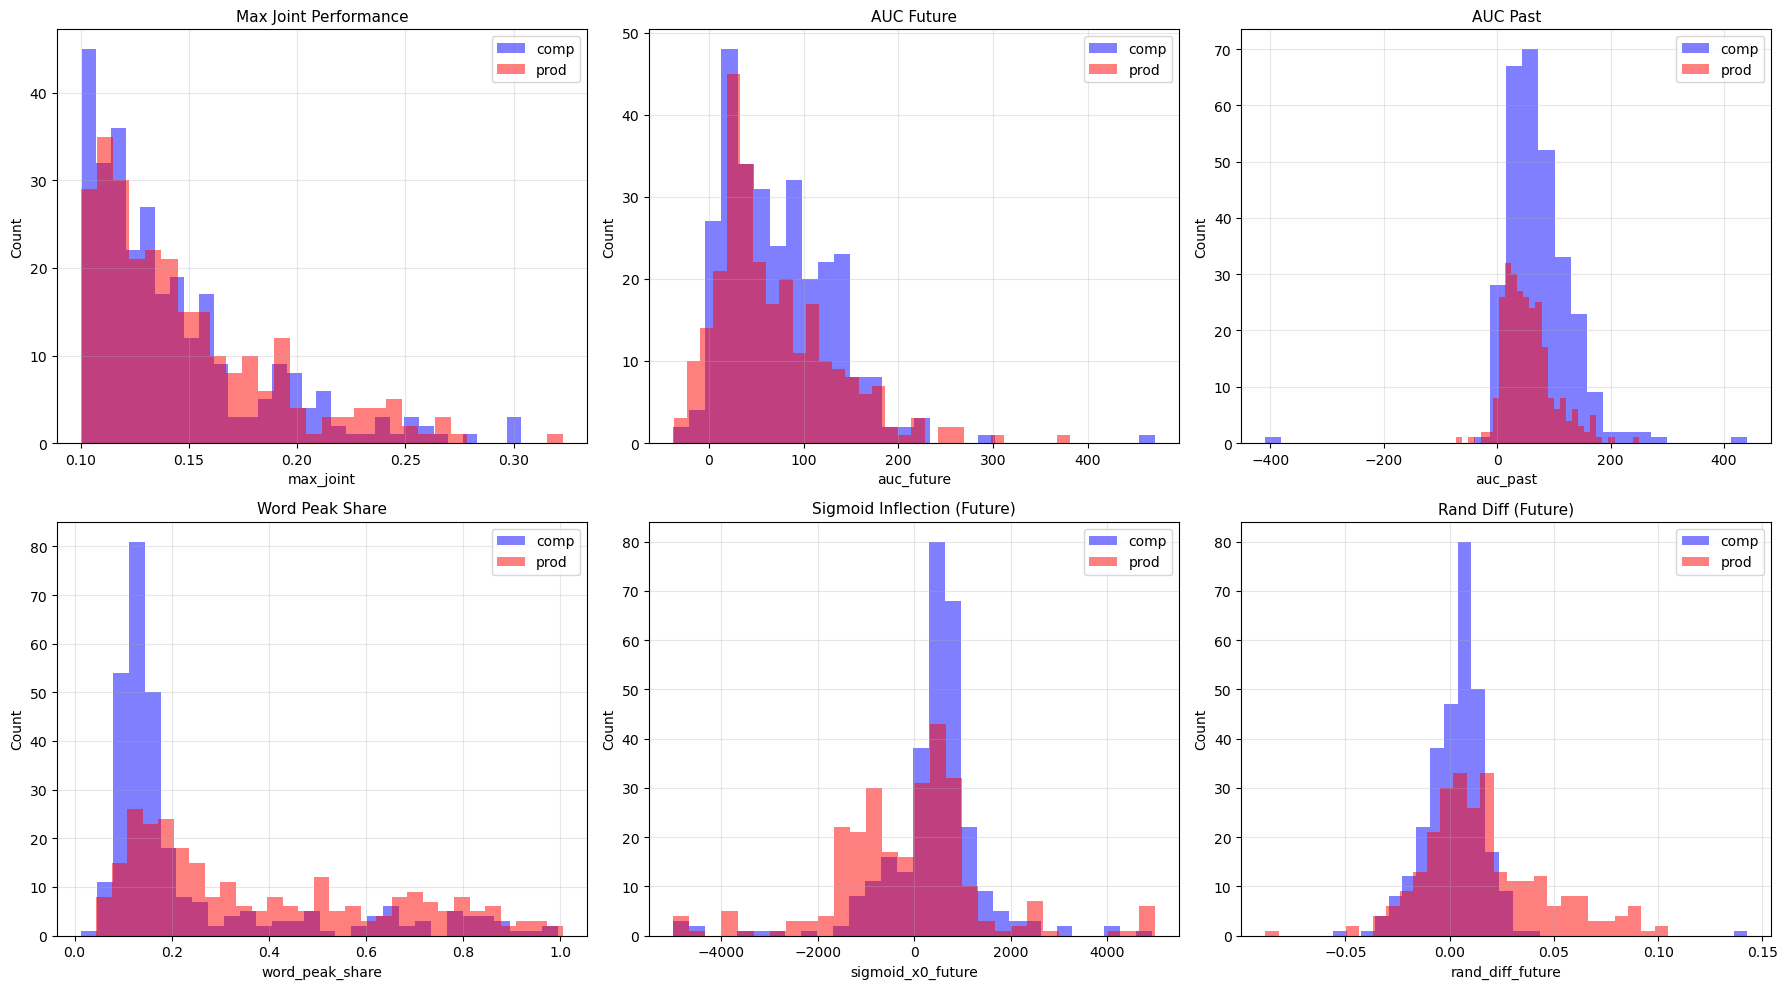


Saved distribution plot to: /scratch/gpfs/HASSON/ij9216/projects/code/247/247-plotting/results/combined_metrics_distributions.png


In [39]:
# Quick visualization: Distribution of key metrics
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics_to_plot = [
    ('max_joint', 'Max Joint Performance'),
    ('auc_future', 'AUC Future'),
    ('auc_past', 'AUC Past'),
    ('word_peak_share', 'Word Peak Share'),
    ('sigmoid_x0_future', 'Sigmoid Inflection (Future)'),
    ('rand_diff_future', 'Rand Diff (Future)')
]

for idx, (metric, title) in enumerate(metrics_to_plot):
    ax = axes[idx // 3, idx % 3]
    
    # Plot distributions for both modes
    for mode, color in [('comp', 'blue'), ('prod', 'red')]:
        data = combined_all[combined_all['mode'] == mode][metric].dropna()
        ax.hist(data, bins=30, alpha=0.5, color=color, label=mode)
    
    ax.set_xlabel(metric, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig(f'{output_dir}/combined_metrics_distributions.png', dpi=150)
plt.show()

print(f"\nSaved distribution plot to: {output_dir}/combined_metrics_distributions.png")

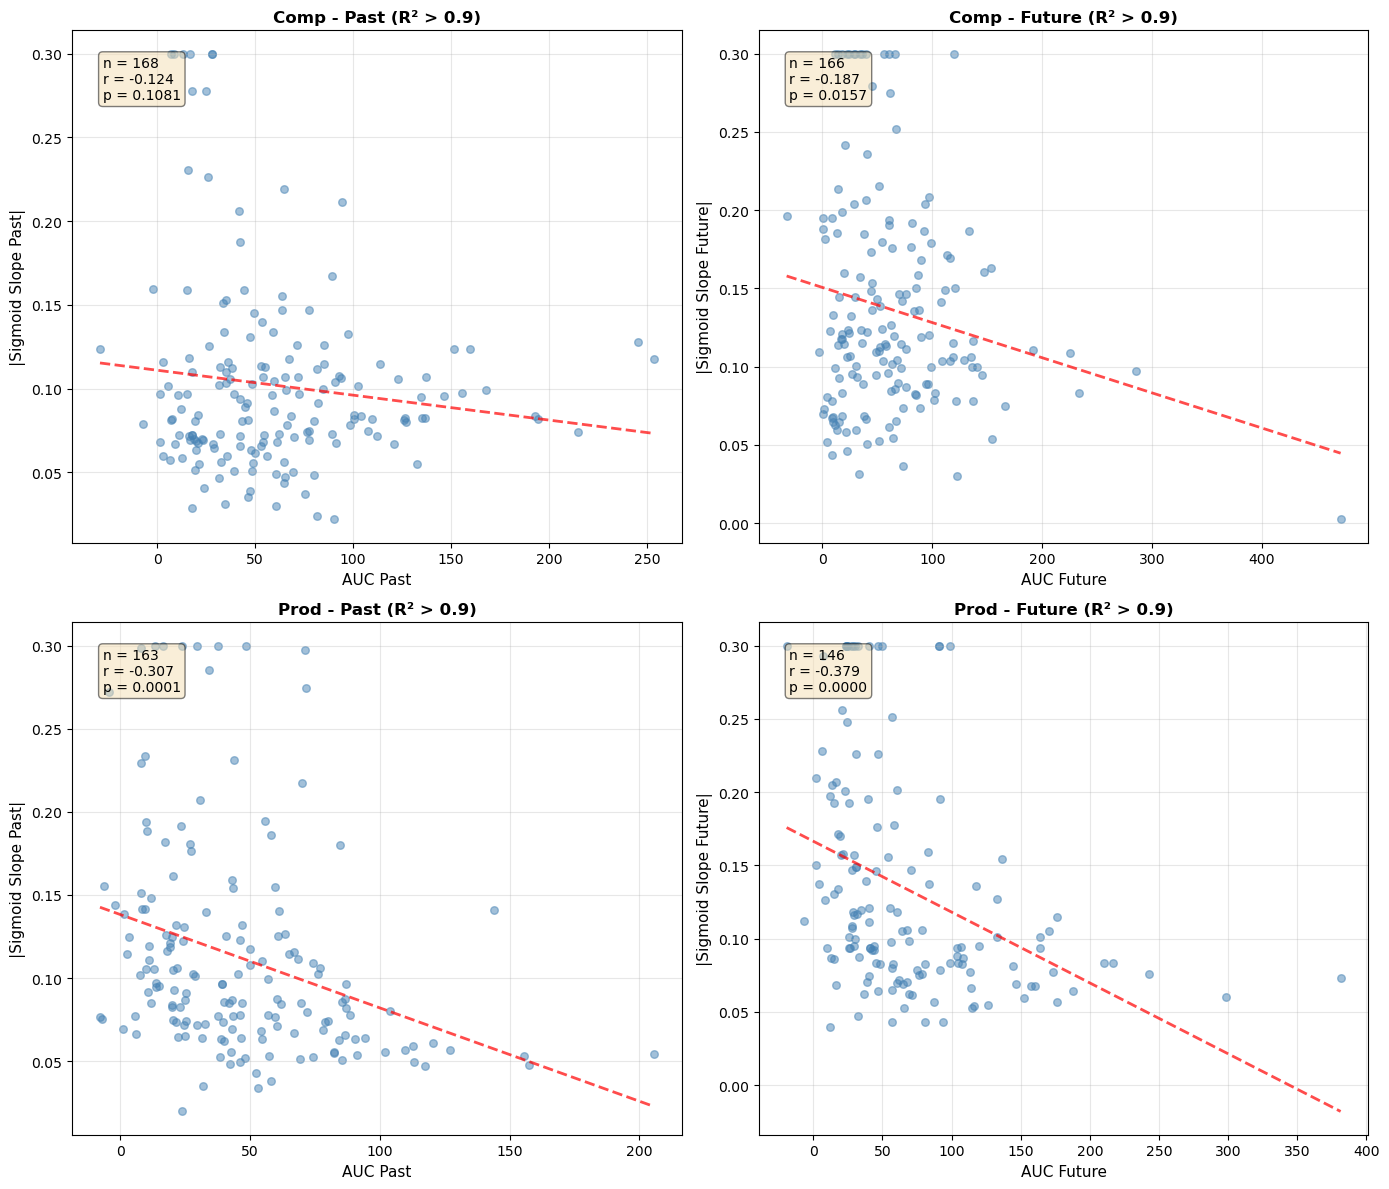


CORRELATION SUMMARY: AUC vs |Sigmoid Slope|
(R² threshold: 0.9)
mode direction   n         r        p     slope
comp      past 168 -0.124400 0.108139 -0.000149
comp    future 166 -0.187184 0.015741 -0.000225
prod      past 163 -0.306699 0.000068 -0.000562
prod    future 146 -0.379047 0.000002 -0.000483


In [45]:
# corrlate auc with slope 
# filter rows by sigmoid_r2>0.9
from scipy.stats import linregress

r2_threshold = 0.9
abs_k_threshold = 0.3
# Create scatterplots of auc vs abs(sigmoid_k) for past, 0future, comp, prod with regression
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Store results for summary table
results = []

for idx, (mode, direction) in enumerate([('comp', 'past'), ('comp', 'future'), ('prod', 'past'), ('prod', 'future')]):
    ax = axes[idx // 2, idx % 2]
    
    # Select appropriate dataframe
    if mode == 'comp':
        data = combined_c_filt.copy()
    else:
        data = combined_p_filt.copy()
    
    # Select appropriate columns based on direction
    if direction == 'past':
        auc_col = 'auc_past'
        k_col = 'sigmoid_k_past'
        r2_col = 'sigmoid_r2_past'
    else:
        auc_col = 'auc_future'
        k_col = 'sigmoid_k_future'
        r2_col = 'sigmoid_r2_future'
    
    # Filter by R² threshold
    filtered = data[data[r2_col] > r2_threshold].copy()
    # set absk>thresh to threshold
    filtered.loc[filtered[k_col].abs() > abs_k_threshold, k_col] = np.sign(filtered.loc[filtered[k_col].abs() > abs_k_threshold, k_col]) * abs_k_threshold
    # Further filter by abs(k) threshold
    # filtered = filtered[filtered[k_col].abs() < abs_k_threshold]
    
    # Add absolute value of k
    filtered['abs_k'] = filtered[k_col].abs()
    
    # Remove NaN values
    plot_data = filtered[[auc_col, 'abs_k']].dropna()
    
    if len(plot_data) > 0:
        x = plot_data[auc_col]
        y = plot_data['abs_k']
        
        # Create scatter plot
        ax.scatter(x, y, alpha=0.5, s=30, color='steelblue')
        
        # Calculate correlation and regression
        if len(x) > 2:
            slope, intercept, r_value, p_value, std_err = linregress(x, y)
            
            # Plot regression line
            x_line = np.array([x.min(), x.max()])
            y_line = slope * x_line + intercept
            ax.plot(x_line, y_line, 'r--', linewidth=2, alpha=0.7, label=f'Fit line')
            
            # Add statistics text box
            stats_text = f'n = {len(x)}\nr = {r_value:.3f}\np = {p_value:.4f}'
            ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
                   verticalalignment='top', fontsize=10,
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
            
            # Store results
            results.append({
                'mode': mode,
                'direction': direction,
                'n': len(x),
                'r': r_value,
                'p': p_value,
                'slope': slope
            })
        
        ax.set_xlabel(f'AUC {direction.capitalize()}', fontsize=11)
        ax.set_ylabel(f'|Sigmoid Slope {direction.capitalize()}|', fontsize=11)
        ax.set_title(f'{mode.capitalize()} - {direction.capitalize()} (R² > {r2_threshold})', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No data passing R² threshold', 
               transform=ax.transAxes, ha='center', va='center')

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*80)
print("CORRELATION SUMMARY: AUC vs |Sigmoid Slope|")
print(f"(R² threshold: {r2_threshold})")
print("="*80)
if results:
    results_df = pd.DataFrame(results)
    print(results_df.to_string(index=False))
else:
    print("No results to display")


In [47]:
# Predict AUC from slope (k) and inflection point (x0) using linear and polynomial regression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

r2_threshold = 0.9

print("="*80)
print("PREDICTING AUC FROM SIGMOID PARAMETERS")
print("="*80)

# Store results
regression_results = []

for mode, direction in [('comp', 'past'), ('comp', 'future'), ('prod', 'past'), ('prod', 'future')]:
    print(f"\n{mode.upper()} - {direction.upper()}")
    print("-"*80)
    
    # Select appropriate dataframe
    if mode == 'comp':
        data = combined_c_filt.copy()
    else:
        data = combined_p_filt.copy()
    
    # Select appropriate columns based on direction
    if direction == 'past':
        auc_col = 'auc_past'
        k_col = 'sigmoid_k_past'
        x0_col = 'sigmoid_x0_past'
        r2_col = 'sigmoid_r2_past'
    else:
        auc_col = 'auc_future'
        k_col = 'sigmoid_k_future'
        x0_col = 'sigmoid_x0_future'
        r2_col = 'sigmoid_r2_future'
    
    # Filter by R² threshold and remove NaN
    filtered = data[data[r2_col] > r2_threshold].copy()
    filtered = filtered[[auc_col, k_col, x0_col]].dropna()
    # set auc<0 to 0
    filtered.loc[filtered[auc_col] < 0, auc_col] = 0
    # set k>0.3 or k<-0.3 to threshold
    filtered.loc[filtered[k_col].abs() > abs_k_threshold, k_col] = np.sign(filtered.loc[filtered[k_col].abs() > abs_k_threshold, k_col]) * abs_k_threshold
    # set auc > 250 to 250
    filtered.loc[filtered[auc_col] > 250, auc_col] = 250   
    if len(filtered) < 10:
        print(f"  Insufficient data: {len(filtered)} samples")
        continue
    
    # Prepare data
    y = filtered[auc_col].values
    X_k = filtered[[k_col]].values  # Just slope
    X_x0 = filtered[[x0_col]].values  # Just inflection point
    X_both = filtered[[k_col, x0_col]].values  # Both features
    
    print(f"  Sample size: {len(filtered)}")
    print(f"  AUC range: [{y.min():.3f}, {y.max():.3f}]")
    print(f"  k range: [{X_k.min():.3f}, {X_k.max():.3f}]")
    print(f"  x0 range: [{X_x0.min():.3f}, {X_x0.max():.3f}]")
    
    # Linear regression models
    print("\n  LINEAR REGRESSION:")
    
    # Model 1: k only
    lr_k = LinearRegression().fit(X_k, y)
    y_pred_k = lr_k.predict(X_k)
    r2_k = r2_score(y, y_pred_k)
    rmse_k = np.sqrt(mean_squared_error(y, y_pred_k))
    cv_k = cross_val_score(LinearRegression(), X_k, y, cv=5, scoring='r2').mean()
    print(f"    k only:       R² = {r2_k:.3f}, RMSE = {rmse_k:.3f}, CV R² = {cv_k:.3f}")
    
    # Model 2: x0 only
    lr_x0 = LinearRegression().fit(X_x0, y)
    y_pred_x0 = lr_x0.predict(X_x0)
    r2_x0 = r2_score(y, y_pred_x0)
    rmse_x0 = np.sqrt(mean_squared_error(y, y_pred_x0))
    cv_x0 = cross_val_score(LinearRegression(), X_x0, y, cv=5, scoring='r2').mean()
    print(f"    x0 only:      R² = {r2_x0:.3f}, RMSE = {rmse_x0:.3f}, CV R² = {cv_x0:.3f}")
    
    # Model 3: k + x0
    lr_both = LinearRegression().fit(X_both, y)
    y_pred_both = lr_both.predict(X_both)
    r2_both = r2_score(y, y_pred_both)
    rmse_both = np.sqrt(mean_squared_error(y, y_pred_both))
    cv_both = cross_val_score(LinearRegression(), X_both, y, cv=5, scoring='r2').mean()
    print(f"    k + x0:       R² = {r2_both:.3f}, RMSE = {rmse_both:.3f}, CV R² = {cv_both:.3f}")
    
    # Polynomial (quadratic) regression models
    print("\n  POLYNOMIAL REGRESSION (degree=2):")
    
    # Model 4: k only (quadratic)
    poly_k = PolynomialFeatures(degree=2, include_bias=False)
    X_k_poly = poly_k.fit_transform(X_k)
    lr_k_poly = LinearRegression().fit(X_k_poly, y)
    y_pred_k_poly = lr_k_poly.predict(X_k_poly)
    r2_k_poly = r2_score(y, y_pred_k_poly)
    rmse_k_poly = np.sqrt(mean_squared_error(y, y_pred_k_poly))
    print(f"    k only:       R² = {r2_k_poly:.3f}, RMSE = {rmse_k_poly:.3f}")
    
    # Model 5: x0 only (quadratic)
    poly_x0 = PolynomialFeatures(degree=2, include_bias=False)
    X_x0_poly = poly_x0.fit_transform(X_x0)
    lr_x0_poly = LinearRegression().fit(X_x0_poly, y)
    y_pred_x0_poly = lr_x0_poly.predict(X_x0_poly)
    r2_x0_poly = r2_score(y, y_pred_x0_poly)
    rmse_x0_poly = np.sqrt(mean_squared_error(y, y_pred_x0_poly))
    print(f"    x0 only:      R² = {r2_x0_poly:.3f}, RMSE = {rmse_x0_poly:.3f}")
    
    # Model 6: k + x0 (quadratic with interaction)
    poly_both = PolynomialFeatures(degree=2, include_bias=False)
    X_both_poly = poly_both.fit_transform(X_both)
    lr_both_poly = LinearRegression().fit(X_both_poly, y)
    y_pred_both_poly = lr_both_poly.predict(X_both_poly)
    r2_both_poly = r2_score(y, y_pred_both_poly)
    rmse_both_poly = np.sqrt(mean_squared_error(y, y_pred_both_poly))
    print(f"    k + x0:       R² = {r2_both_poly:.3f}, RMSE = {rmse_both_poly:.3f}")
    
    # Store results
    regression_results.append({
        'mode': mode,
        'direction': direction,
        'n': len(filtered),
        'linear_k_r2': r2_k,
        'linear_k_cv': cv_k,
        'linear_x0_r2': r2_x0,
        'linear_x0_cv': cv_x0,
        'linear_both_r2': r2_both,
        'linear_both_cv': cv_both,
        'poly_k_r2': r2_k_poly,
        'poly_x0_r2': r2_x0_poly,
        'poly_both_r2': r2_both_poly
    })

# Summary table
print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
if regression_results:
    results_df = pd.DataFrame(regression_results)
    print(results_df.to_string(index=False))
    
    print("\n" + "="*80)
    print("KEY FINDINGS:")
    print("="*80)
    for _, row in results_df.iterrows():
        best_model = 'linear_k'
        best_r2 = row['linear_k_r2']
        
        models = {
            'linear_k': row['linear_k_r2'],
            'linear_x0': row['linear_x0_r2'],
            'linear_both': row['linear_both_r2'],
            'poly_k': row['poly_k_r2'],
            'poly_x0': row['poly_x0_r2'],
            'poly_both': row['poly_both_r2']
        }
        
        best_model = max(models, key=models.get)
        best_r2 = models[best_model]
        
        print(f"{row['mode']} {row['direction']}: Best model = {best_model} (R² = {best_r2:.3f})")


PREDICTING AUC FROM SIGMOID PARAMETERS

COMP - PAST
--------------------------------------------------------------------------------
  Sample size: 168
  AUC range: [0.000, 250.000]
  k range: [-0.300, -0.022]
  x0 range: [-2186.980, 1865.449]

  LINEAR REGRESSION:
    k only:       R² = 0.015, RMSE = 47.027, CV R² = -0.582
    x0 only:      R² = 0.244, RMSE = 41.219, CV R² = -0.081
    k + x0:       R² = 0.301, RMSE = 39.630, CV R² = -0.144

  POLYNOMIAL REGRESSION (degree=2):
    k only:       R² = 0.066, RMSE = 45.809
    x0 only:      R² = 0.252, RMSE = 40.982
    k + x0:       R² = 0.362, RMSE = 37.870

COMP - FUTURE
--------------------------------------------------------------------------------
  Sample size: 166
  AUC range: [0.000, 250.000]
  k range: [0.002, 0.300]
  x0 range: [-976.437, 2996.838]

  LINEAR REGRESSION:
    k only:       R² = 0.026, RMSE = 49.235, CV R² = -0.890
    x0 only:      R² = 0.194, RMSE = 44.792, CV R² = -0.318
    k + x0:       R² = 0.288, RMSE = 42

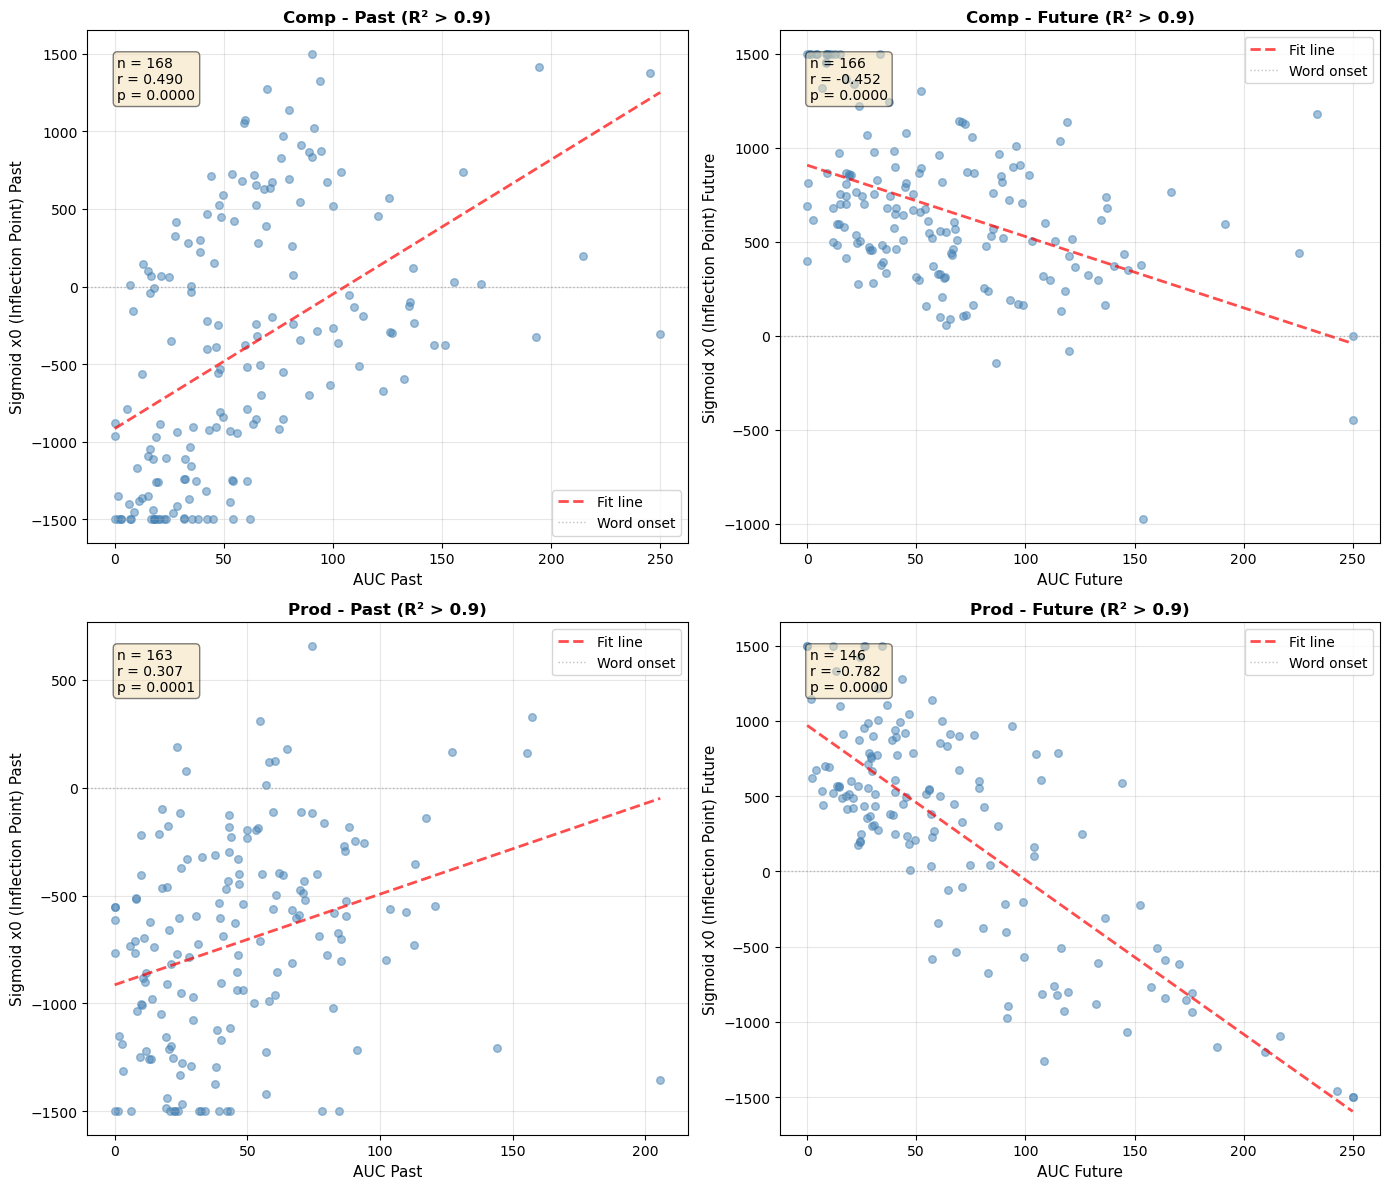


CORRELATION SUMMARY: AUC vs Sigmoid x0 (Inflection Point)
(R² threshold: 0.9)
mode direction   n         r            p      slope
comp      past 168  0.489976 1.574415e-11   8.662537
comp    future 166 -0.452131 9.658642e-10  -3.791180
prod      past 163  0.306559 6.890894e-05   4.200669
prod    future 146 -0.782029 2.277766e-31 -10.256561


In [49]:
# Scatterplots of AUC vs x0 (inflection point)
from scipy.stats import linregress

r2_threshold = 0.9

# Create scatterplots of auc vs x0 for past, future, comp, prod with regression
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Store results for summary table
results_x0 = []

for idx, (mode, direction) in enumerate([('comp', 'past'), ('comp', 'future'), ('prod', 'past'), ('prod', 'future')]):
    ax = axes[idx // 2, idx % 2]
    
    # Select appropriate dataframe
    if mode == 'comp':
        data = combined_c_filt.copy()
    else:
        data = combined_p_filt.copy()
    
    # Select appropriate columns based on direction
    if direction == 'past':
        auc_col = 'auc_past'
        x0_col = 'sigmoid_x0_past'
        r2_col = 'sigmoid_r2_past'
    else:
        auc_col = 'auc_future'
        x0_col = 'sigmoid_x0_future'
        r2_col = 'sigmoid_r2_future'
    
    # Filter by R² threshold
    filtered = data[data[r2_col] > r2_threshold].copy()
    # set auc<0 to 0, and auc>250 to 250
    filtered.loc[filtered[auc_col] < 0, auc_col] = 0
    filtered.loc[filtered[auc_col] > 250, auc_col] = 250
    # set x0<-1500 to -1500 or x0>1500 to 1500
    filtered.loc[filtered[x0_col] < -1500, x0_col] = -1500
    filtered.loc[filtered[x0_col] > 1500, x0_col] = 1500
    
    # Remove NaN values
    plot_data = filtered[[auc_col, x0_col]].dropna()
    
    if len(plot_data) > 0:
        x = plot_data[auc_col].values
        y = plot_data[x0_col].values
        
        # Create scatter plot
        ax.scatter(x, y, alpha=0.5, s=30, color='steelblue')
        
        # Calculate correlation and regression
        if len(x) > 2:
            slope, intercept, r_value, p_value, std_err = linregress(x, y)
            
            # Plot regression line
            x_line = np.array([x.min(), x.max()])
            y_line = slope * x_line + intercept
            ax.plot(x_line, y_line, 'r--', linewidth=2, alpha=0.7, label=f'Fit line')
            
            # Add statistics text box
            stats_text = f'n = {len(x)}\nr = {r_value:.3f}\np = {p_value:.4f}'
            ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
                   verticalalignment='top', fontsize=10,
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
            
            # Store results
            results_x0.append({
                'mode': mode,
                'direction': direction,
                'n': len(x),
                'r': r_value,
                'p': p_value,
                'slope': slope
            })
        
        ax.set_xlabel(f'AUC {direction.capitalize()}', fontsize=11)
        ax.set_ylabel(f'Sigmoid x0 (Inflection Point) {direction.capitalize()}', fontsize=11)
        ax.set_title(f'{mode.capitalize()} - {direction.capitalize()} (R² > {r2_threshold})', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # Add horizontal line at x0=0 (word onset)
        ax.axhline(y=0, color='gray', linestyle=':', linewidth=1, alpha=0.5, label='Word onset')
        ax.legend()
    else:
        ax.text(0.5, 0.5, 'No data passing R² threshold', 
               transform=ax.transAxes, ha='center', va='center')

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*80)
print("CORRELATION SUMMARY: AUC vs Sigmoid x0 (Inflection Point)")
print(f"(R² threshold: {r2_threshold})")
print("="*80)
if results_x0:
    results_df = pd.DataFrame(results_x0)
    print(results_df.to_string(index=False))
else:
    print("No results to display")


In [ ]:
print("="*80)
print("ELECTRODE PLOTTING SUMMARY")
print("="*80)
print(f"Comprehension PDF: {output_pdf_comp}")
print(f"  Total electrodes plotted: {len(combined_c_filt)}")
print(f"\nProduction PDF: {output_pdf_prod}")
print(f"  Total electrodes plotted: {len(combined_p_filt)}")
print(f"\nEach plot contains:")
print("  - Time series: Joint, Word, Future (sentence), Past (sentence2)")
print("  - X-axis: Time in milliseconds (not lag index)")
print("  - Vertical line at word onset (lag=0)")
print("  - Text box with all metrics:")
print("    * max_joint, AUC_past, AUC_future, word_peak_share")
print("    * sigmoid_slope_k, sigmoid_inflection_x0")
print("    * future_diff_rand, past_diff_rand")
print("    * future_diff_opp, past_diff_opp")

## Plot All Electrodes to PDF

Create comprehensive time-series plots for all electrodes in combined_c_filt and combined_p_filt, showing:
- Joint, word, future (sentence), and past (sentence2) performance over time
- All metrics displayed as text annotations

In [31]:
def plot_electrode_timeseries(electrode_data, no_reph_data, lag_cols, metrics, ax, title):
    """
    Plot time series for one electrode showing joint, word, future, and past.
    
    Parameters:
    - electrode_data: Row from combined_c_filt or combined_p_filt with metrics
    - no_reph_data: Original data (no_reph_c or no_reph_p) with time series
    - lag_cols: Array of lag values (in ms)
    - metrics: Dict of metric values to display
    - ax: Matplotlib axis to plot on
    - title: Title for the plot
    """
    # Convert lags to time (ms)
    time_ms = lag_cols
    
    # Get electrode identifier
    subject = electrode_data['subject']
    electrode = electrode_data['electrode']
    
    # Extract time series from no_reph_data
    elec_mask = (no_reph_data['subject'] == subject) & (no_reph_data['electrode'] == electrode)
    
    # Plot each condition
    for label3, color, label in [
        ('joint', '#1f77b4', 'Joint'),
        ('word', '#2ca02c', 'Word'),
        ('sentence', '#ff7f0e', 'Future'),
        ('sentence2', '#d62728', 'Past')
    ]:
        condition_data = no_reph_data[(no_reph_data['label3'] == label3) & elec_mask]
        if len(condition_data) > 0:
            values = condition_data.iloc[0][lag_cols].values
            ax.plot(time_ms, values, color=color, label=label, linewidth=1.5, alpha=0.8)
    
    # Add vertical line at word onset (lag=0)
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Word onset')
    
    # Formatting
    ax.set_xlabel('Time (ms)', fontsize=10)
    ax.set_ylabel('Correlation', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(loc='upper left', fontsize=8, framealpha=0.9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(time_ms[0], time_ms[-1])
    ax.set_ylim(-0.20, 0.3)  # Fixed y-axis limit
    
    # Add metrics text box outside the plot
    metrics_text = "\n".join([f"{key}: {value:.2f}" if isinstance(value, float) else f"{key}: {value}" 
                              for key, value in metrics.items()])
    ax.figure.subplots_adjust(left=0.3)  # Adjust the left margin to make space for the text box
    ax.text(-0.35, 0.5, metrics_text, transform=ax.transAxes, 
            fontsize=10,  # Increased font size
            verticalalignment='center', horizontalalignment='left',
            fontfamily='Nimbus Sans',  # Set font to Roboto Mono
            bbox=dict(boxstyle='round', facecolor='lightgrey', alpha=0.8))  # Light grey background

In [35]:
# load data
from scipy.stats import percentileofscore

combined_all = pd.read_csv('/scratch/gpfs/HASSON/ij9216/projects/code/247/247-plotting/results/combined_metrics_all_thresh0.1.csv')
combined_c_filt = pd.read_csv('/scratch/gpfs/HASSON/ij9216/projects/code/247/247-plotting/results/combined_metrics_comp_thresh0.1.csv')
combined_p_filt = pd.read_csv('/scratch/gpfs/HASSON/ij9216/projects/code/247/247-plotting/results/combined_metrics_prod_thresh0.1.csv')

# Add percentile and category columns for metrics
def add_percentile_and_category(df, metric_cols):
    """Add percentile and category (low/mid/high) columns for each metric."""
    for col in metric_cols:
        if col in df.columns:
            # Calculate percentile for each value
            df[f'{col}_percentile'] = df[col].apply(lambda x: percentileofscore(df[col].dropna(), x, kind='rank') if pd.notna(x) else np.nan)
            
            # Categorize as low (<33.3%), mid (33.3-66.6%), high (>66.6%)
            df[f'{col}_category'] = pd.cut(
                df[f'{col}_percentile'], 
                bins=[0, 33.33, 66.67, 100], 
                labels=['low', 'mid', 'high'],
                include_lowest=True
            )
    return df

# Define metric columns (excluding metadata)
metric_cols = [
    'max_joint', 'auc_past', 'auc_future', 'word_peak_share',
    'sigmoid_k_past', 'sigmoid_k_future', 'sigmoid_x0_past', 'sigmoid_x0_future',
    'rand_diff_future', 'rand_diff_past', 'opp_diff_future', 'opp_diff_past'
]

print("Adding percentiles and categories for comprehension...")
combined_c_filt = add_percentile_and_category(combined_c_filt, metric_cols)

print("Adding percentiles and categories for production...")
combined_p_filt = add_percentile_and_category(combined_p_filt, metric_cols)

print("Percentile and category columns added!")

res_d = "/scratch/gpfs/HASSON/ij9216/projects/code/247/247-encoding-dev/results/tfs"
thresh_joint = 0.1
# Load original (no rephrase) data - 60k lag range
print("Loading original data (60k lag range)...")
no_reph_c = pu.load_res_add_roi_threshold(
    f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-reph-translate-control_pca300_drop-short_mistral_comp.csv", 
    None
)
no_reph_p = pu.load_res_add_roi_threshold(
    f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-reph-translate-control_pca300_drop-short_mistral_prod.csv", 
    None
)

# Rename lag columns to numeric values
lag_cols = np.arange(-60000, 60001, 50)
for df in [no_reph_c, no_reph_p]:
    n_lag_cols = len(lag_cols)
    new_columns = list(lag_cols) + list(df.columns[n_lag_cols:])
    df.columns = new_columns

# Select lag columns in the range -20000 to 20001 with a step of 50
selected_lag_cols = np.arange(-20000, 20001, 50)

# Filter the DataFrame to include only the selected lag columns
for df in [no_reph_c, no_reph_p]:
    df = df[['subject', 'electrode', 'label3'] + list(selected_lag_cols)]

print(f"Comprehension shape (60k): {no_reph_c.shape}")
print(f"Production shape (60k): {no_reph_p.shape}")

Adding percentiles and categories for comprehension...
Adding percentiles and categories for production...
Adding percentiles and categories for production...
Percentile and category columns added!
Loading original data (60k lag range)...
Percentile and category columns added!
Loading original data (60k lag range)...
Comprehension shape (60k): (2644, 2406)
Production shape (60k): (2644, 2406)
Comprehension shape (60k): (2644, 2406)
Production shape (60k): (2644, 2406)


In [36]:
# Create PDF with all production electrode plots
output_pdf_prod = '/scratch/gpfs/HASSON/ij9216/projects/code/247/247-plotting/results/roi_figures/all_electrodes_prod.pdf'

print(f"Creating production electrode plots PDF...")
print(f"  Number of electrodes: {len(combined_p_filt)}")
print(f"  Output: {output_pdf_prod}")

with PdfPages(output_pdf_prod) as pdf:
    for idx, row in combined_p_filt.iterrows():
        fig, ax = plt.subplots(figsize=(14, 6))
        
        # Prepare metrics dictionary with categories
        def format_metric(value, category):
            """Format metric value with category in brackets."""
            if pd.isna(value):
                return 'NaN'
            elif pd.isna(category):
                return f'{value:.2f}'
            else:
                return f'{value:.2f} ({category})'
        
        metrics = {
            'Subject': row['subject'],
            'Electrode': row['electrode'],
            'ROI': row['roi'],
            'Max Joint': format_metric(row['max_joint'], row.get('max_joint_category')),
            'AUC Past': format_metric(row['auc_past'], row.get('auc_past_category')),
            'AUC Future': format_metric(row['auc_future'], row.get('auc_future_category')),
            'Word Peak Share': format_metric(row['word_peak_share'], row.get('word_peak_share_category')),
            'Sigmoid k past': format_metric(row['sigmoid_k_past'], row.get('sigmoid_k_past_category')),
            'Sigmoid k future': format_metric(row['sigmoid_k_future'], row.get('sigmoid_k_future_category')),
            'Sigmoid x0 past': format_metric(row['sigmoid_x0_past'], row.get('sigmoid_x0_past_category')),
            'Sigmoid x0 future': format_metric(row['sigmoid_x0_future'], row.get('sigmoid_x0_future_category')),
            'Future Diff Rand': format_metric(row['rand_diff_future'], row.get('rand_diff_future_category')),
            'Past Diff Rand': format_metric(row['rand_diff_past'], row.get('rand_diff_past_category')),
            'Future Diff Opp': format_metric(row['opp_diff_future'], row.get('opp_diff_future_category')),
            'Past Diff Opp': format_metric(row['opp_diff_past'], row.get('opp_diff_past_category'))
        }
        
        # Create title
        title = f"Production - Subject {row['subject']} - Electrode {row['electrode']} - ROI: {row['roi']}"
        
        # Plot
        plot_electrode_timeseries(row, no_reph_p, selected_lag_cols, metrics, ax, title)
        
        # Save to PDF
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)
        
        # Print progress
        if (idx + 1) % 10 == 0:
            print(f"  Processed {idx + 1}/{len(combined_p_filt)} electrodes")

print(f"  Complete! Saved to {output_pdf_prod}")

Creating production electrode plots PDF...
  Number of electrodes: 266
  Output: /scratch/gpfs/HASSON/ij9216/projects/code/247/247-plotting/results/roi_figures/all_electrodes_prod.pdf
  Processed 10/266 electrodes
  Processed 10/266 electrodes
  Processed 20/266 electrodes
  Processed 20/266 electrodes
  Processed 30/266 electrodes
  Processed 30/266 electrodes
  Processed 40/266 electrodes
  Processed 40/266 electrodes
  Processed 50/266 electrodes
  Processed 50/266 electrodes
  Processed 60/266 electrodes
  Processed 60/266 electrodes
  Processed 70/266 electrodes
  Processed 70/266 electrodes
  Processed 80/266 electrodes
  Processed 80/266 electrodes
  Processed 90/266 electrodes
  Processed 90/266 electrodes
  Processed 100/266 electrodes
  Processed 100/266 electrodes
  Processed 110/266 electrodes
  Processed 110/266 electrodes
  Processed 120/266 electrodes
  Processed 120/266 electrodes
  Processed 130/266 electrodes
  Processed 130/266 electrodes
  Processed 140/266 electrod

In [37]:
# Create PDF with all comprehension electrode plots
output_pdf_comp = '/scratch/gpfs/HASSON/ij9216/projects/code/247/247-plotting/results/roi_figures/all_electrodes_comp.pdf'

# Helper function to format metric with category
def format_metric(value, category):
    """Format a metric value with its category in brackets"""
    if pd.isna(value):
        return 'N/A'
    if pd.isna(category):
        return f'{value:.4f}'
    return f'{value:.4f} ({category})'

print(f"Creating comprehension electrode plots PDF...")
print(f"  Number of electrodes: {len(combined_c_filt)}")
print(f"  Output: {output_pdf_comp}")

with PdfPages(output_pdf_comp) as pdf:
    for idx, row in combined_c_filt.iterrows():
        fig, ax = plt.subplots(figsize=(14, 6))
        
        # Prepare metrics dictionary with categories
        metrics = {
            'Subject': row['subject'],
            'Electrode': row['electrode'],
            'ROI': row['roi'],
            'Max Joint': format_metric(row['max_joint'], row.get('max_joint_category')),
            'AUC Past': format_metric(row['auc_past'], row.get('auc_past_category')),
            'AUC Future': format_metric(row['auc_future'], row.get('auc_future_category')),
            'Word Peak Share': format_metric(row['word_peak_share'], row.get('word_peak_share_category')),
            'Sigmoid k past': format_metric(row['sigmoid_k_past'], row.get('sigmoid_k_past_category')),
            'Sigmoid k future': format_metric(row['sigmoid_k_future'], row.get('sigmoid_k_future_category')),
            'Sigmoid x0 past': format_metric(row['sigmoid_x0_past'], row.get('sigmoid_x0_past_category')),
            'Sigmoid x0 future': format_metric(row['sigmoid_x0_future'], row.get('sigmoid_x0_future_category')),
            'Future Diff Rand': format_metric(row['rand_diff_future'], row.get('rand_diff_future_category')),
            'Past Diff Rand': format_metric(row['rand_diff_past'], row.get('rand_diff_past_category')),
            'Future Diff Opp': format_metric(row['opp_diff_future'], row.get('opp_diff_future_category')),
            'Past Diff Opp': format_metric(row['opp_diff_past'], row.get('opp_diff_past_category'))
        }
        
        # Create title
        title = f"Comprehension - Subject {row['subject']} - Electrode {row['electrode']} - ROI: {row['roi']}"
        
        # Plot
        plot_electrode_timeseries(row, no_reph_c, lag_cols, metrics, ax, title)
        
        # Save to PDF
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)
        
        # Print progress
        if (idx + 1) % 10 == 0:
            print(f"  Processed {idx + 1}/{len(combined_c_filt)} electrodes")

print(f"  Complete! Saved to {output_pdf_comp}")

Creating comprehension electrode plots PDF...
  Number of electrodes: 292
  Output: /scratch/gpfs/HASSON/ij9216/projects/code/247/247-plotting/results/roi_figures/all_electrodes_comp.pdf
  Processed 10/292 electrodes
  Processed 20/292 electrodes
  Processed 30/292 electrodes
  Processed 40/292 electrodes
  Processed 50/292 electrodes
  Processed 60/292 electrodes
  Processed 70/292 electrodes
  Processed 80/292 electrodes
  Processed 90/292 electrodes
  Processed 100/292 electrodes
  Processed 110/292 electrodes
  Processed 120/292 electrodes
  Processed 130/292 electrodes
  Processed 140/292 electrodes
  Processed 150/292 electrodes
  Processed 160/292 electrodes
  Processed 170/292 electrodes
  Processed 180/292 electrodes
  Processed 190/292 electrodes
  Processed 200/292 electrodes
  Processed 210/292 electrodes
  Processed 220/292 electrodes
  Processed 230/292 electrodes
  Processed 240/292 electrodes
  Processed 250/292 electrodes
  Processed 260/292 electrodes
  Processed 270/